# 🛰️ GFM Flood Observation – Time Series Animation from STAC to Video

### Introduction

The **Global Flood Monitoring (GFM)** system by the **Copernicus Emergency Management Service (CEMS)** provides near-real-time flood information derived from Sentinel-1 radar imagery.  
These products enable rapid assessment of flood extent and dynamics anywhere on Earth — independent of cloud cover or daylight.

This notebook demonstrates how to transform **GFM flood-extent time series** into a high-quality animated video showing flood evolution over time.

### Storyline

We start with **GFM ensemble flood-extent rasters** (`ensemble_flood_extent`), which represent flooded pixels (value > 0) across multiple Sentinel-1 acquisition dates.  
Each pixel indicates whether water was detected during a specific satellite pass.  
By stacking these time slices, we can visualize **how the flood evolved day by day**.

The workflow proceeds step by step:

1. **Query STAC API** — Search the GFM collection for items matching your AOI and time range.  
2. **Load rasters via ODC-STAC** — Fetch flood extent data and reproject to EPSG:4326.  
3. **Export per-day PNG overlays** — Generate transparent blue flood masks for each timestep.  
4. **Build cumulative overlays** — Create fading effect where newer floods appear more intense.  
5. **Render video with basemap** — Combine OSM basemap, flood overlays, and area chart into animated frames.  
6. **Export GIF and interactive player** — Generate `.gif` animation and embed interactive HTML5 player.

### Purpose

This notebook provides a **complete end-to-end workflow** for flood animation:

- Convert temporal flood rasters into visual time-series animations.  
- Overlay flood data on real-world basemaps for geographic context.  
- Generate publication-ready or presentation-ready videos with charts and legends.  
- Support interactive exploration with embedded HTML5 players.

Such processing can be applied to any AOI, from local river basins to continental scales,  
supporting flood-event communication, post-event analysis, and public awareness campaigns within the **CLIMAAX** or **CEMS-GFM** frameworks.


## Load libraries

We import geospatial and visualization libraries and set basic paths.


In [1]:
from shapely.geometry import box, mapping
from pystac_client import Client
from odc import stac as odc_stac
import pyproj
import rioxarray
import xarray as xr
from tqdm.notebook import tqdm
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio
import matplotlib.image as mpimg
import os, io, re, math, warnings, subprocess, requests, shutil, base64, json
from datetime import datetime
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import rasterio
from rasterio.transform import from_bounds, Affine
from rasterio.warp import reproject, Resampling
from IPython.display import display, HTML
import ipywidgets as widgets
from ipyleaflet import Map, DrawControl, Rectangle
import warnings, io, os, re, math, subprocess, requests, shutil, base64

# Handy switches and paths
FLOOD_DIR = "flood_frames"
STAC_URL  = "https://stac.eodc.eu/api/v1"
COLLECTION_ID = "GFM"

os.makedirs(FLOOD_DIR, exist_ok=True)

## Draw an Area of Interest (AOI) 🗺️

Use the map below to **draw a rectangle** around the area you want to analyze.  

⚠️ Rules for drawing:  
- Only rectangles are allowed (no polygons, lines or circles).  
- To keep things efficient, a **size limit** is enforced:  
  – the sum of width + height of the rectangle must be ≤ `MAX_SIZE` degrees.  
- If your selection is too large, you'll see a warning and the AOI won't be accepted.  

After drawing, the **selected bounding box** (min/max longitude/latitude) will be printed under the map.  
The default bounding box is shown in **green**, and your new selection will appear in **red**.


In [2]:
from IPython.display import clear_output
clear_output(wait=True)


from shapely.geometry import shape

# Create map
from ipyleaflet import TileLayer
basemap_carto = TileLayer(url="https://basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png", attribution="© OpenStreetMap contributors © CARTO")

m = Map(basemap=basemap_carto, center=(39.19075, -8.711347), zoom=11)

# Accept only rectangle
draw_control = DrawControl(
    rectangle={"shapeOptions": {"color": "#3388ff", "fillOpacity": 0.1}},
    polygon={}, circle={}, circlemarker={}, polyline={}
)

output = widgets.Output()

# Max allowed size (width + height in degrees)
MAX_SIZE = 2

# Default bbox (minx, miny, maxx, maxy)
default_bbox = (-8.711347, 39.19075, -8.610075, 39.265216)


# Keep current selection here
selected_bbox = {
    "minx": default_bbox[0],
    "miny": default_bbox[1],
    "maxx": default_bbox[2],
    "maxy": default_bbox[3]
}

# Draw default rectangle on the map
last_rect = Rectangle(
    bounds=((default_bbox[1], default_bbox[0]), (default_bbox[3], default_bbox[2])),
    color="green",
    fill_opacity=0.2
)
m.add_layer(last_rect)

with output:
    print("Default bounding box:", selected_bbox)

# Callback for draw events
def handle_draw(_, action, geo_json):
    global selected_bbox, last_rect

    # Remove old rectangle
    if last_rect in m.layers:
        m.remove_layer(last_rect)

    if geo_json["geometry"]["type"] == "Polygon":
        geom = shape(geo_json["geometry"])
        minx, miny, maxx, maxy = geom.bounds
        width = maxx - minx
        height = maxy - miny
        size = width + height

        with output:
            output.clear_output()
            if size > MAX_SIZE:
                print(f"⚠️ Bounding box is too big! "
                      f"Max (width+height): {MAX_SIZE}°, "
                      f"currently: {size:.3f}° (width {width:.3f}°, height {height:.3f}°)")
                selected_bbox = {}
            else:
                selected_bbox = {"minx": minx, "miny": miny, "maxx": maxx, "maxy": maxy}
                # Draw new rectangle
                new_rect = Rectangle(bounds=((miny, minx), (maxy, maxx)),
                                     color="red", fill_opacity=0.2)
                m.add_layer(new_rect)
                # Track it
                globals()["last_rect"] = new_rect
                print("Selected bounding box:", selected_bbox)

draw_control.on_draw(handle_draw)
m.add_control(draw_control)

display(m, output)


Map(center=[39.19075, -8.711347], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', …

Output()

## Pick a date range 📅

Flood layers are stored **day by day**.  
To analyze a specific flood, you need to know **when the event happened**.  

- Select the start and end dates that cover the flood period.  
- The notebook will load all available GFM flood maps in this range.  


In [3]:
from datetime import date, timedelta
from IPython.display import display, clear_output

# DatePickers
start_picker = widgets.DatePicker(
    description="From:",
    value=date(2026, 1, 27),
    disabled=False
)
end_picker = widgets.DatePicker(
    description="To:",
    value=date(2026, 2, 17),
    disabled=False
)
output = widgets.Output()
selected_dates = []

def update_range(change=None):
    global selected_dates
    if start_picker.value and end_picker.value:
        start = start_picker.value
        end = end_picker.value
        with output:
            output.clear_output()
            if start > end:
                print("⚠️ The start date must be earlier than or equal to the end date.")
                selected_dates = []
                return
            selected_dates = [(start + timedelta(days=i)).isoformat()
                              for i in range((end - start).days + 1)]
            print("Selected dates:", selected_dates[:3], "...", selected_dates[-3:] if len(selected_dates) > 3 else selected_dates)

start_picker.observe(update_range, names="value")
end_picker.observe(update_range, names="value")

# Initialize
update_range()

display(widgets.HBox([start_picker, end_picker]), output)


Output()

## Prepare AOI geometry and time range 🗂️

Before we can query flood data, we need two things:

1. **Area of Interest (AOI):**  
   The rectangle you drew on the map is converted into a Shapely geometry object.  
   – This gives us exact bounding box coordinates (min/max longitude & latitude).  

2. **Time range:**  
   The dates you selected earlier are combined into a start and end date.  
   – This tells the STAC API which flood images to load.  

Both the AOI bounds and the selected time range are printed below for verification.


In [4]:
# Create Shapely geometry for AOI from 'selected_bbox'
if selected_bbox:
    aoi_geometry = box(selected_bbox["minx"], selected_bbox["miny"],
                       selected_bbox["maxx"], selected_bbox["maxy"])
else:
    aoi_geometry = None

# Build time range from selected dates
if 'selected_dates' in globals() and selected_dates:
    time_range = (selected_dates[0], selected_dates[-1])
else:
    time_range = None

print("AOI geometry:", aoi_geometry)
if aoi_geometry:
    print("AOI bounds:", aoi_geometry.bounds)
print("Time range:", time_range)

AOI geometry: POLYGON ((-8.610075 39.19075, -8.610075 39.265216, -8.711347 39.265216, -8.711347 39.19075, -8.610075 39.19075))
AOI bounds: (-8.711347, 39.19075, -8.610075, 39.265216)
Time range: ('2026-01-27', '2026-02-17')


## Query the STAC API 🔍

Search the **GFM** collection for items intersecting the AOI within the time window.

Process:

1. **Connect to STAC API:**  
   – Uses [EODC STAC endpoint](https://stac.eodc.eu/api/v1)  
   – Queries the GFM collection

2. **Spatial and temporal filtering:**  
   – AOI geometry (your drawn rectangle)  
   – Selected date range

✅ **Output:**  
– Number of matching STAC items found  
– List of flood raster metadata


In [5]:
client = Client.open(STAC_URL)

search = client.search(
    collections=[COLLECTION_ID],
    intersects=mapping(aoi_geometry),
    datetime=f"{time_range[0]}/{time_range[1]}"
)

items = search.item_collection()
print(f"🔍 Found {len(items)} items.")
if len(items) == 0:
    raise RuntimeError("No STAC items found for the given AOI/time range.")


🔍 Found 125 items.


## Load rasters via ODC-STAC

We extract source CRS/GSD from the first item, load `ensemble_flood_extent`, and reproject to **EPSG:4326** for visualization and bounds.


In [6]:

# Extract CRS and nominal resolution (gsd) from the first item
crs = pyproj.CRS.from_wkt(items[0].properties["proj:wkt2"])
resolution = items[0].properties.get("gsd", None)
print("Source CRS:", crs)
print("GSD (m):", resolution)

# Desired band
bands = ["ensemble_flood_extent"]

# Load cube (fail_on_error=False so it doesn't crash on a single file).
# groupby="solar_day" mosaics every item acquired on the same day (overlapping
# passes / adjacent tiles) into ONE time slice, instead of letting each item
# become its own duplicate frame. Lossless dedup of same-day scenes -> one
# frame per day downstream.
xx = odc_stac.load(
    items,
    crs=crs,
    bbox=aoi_geometry.bounds,
    bands=bands,
    resolution=resolution,
    groupby="solar_day",
    dtype="uint8",
    fail_on_error=False,
)
print(f"STAC items: {len(items)} -> time slices after solar_day dedup: {xx.sizes['time']}")

# Reproject to WGS84 for visualization / bounds extraction
xx = xx.rio.reproject("EPSG:4326")


Source CRS: PROJCS["Azimuthal_Equidistant",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",53],PARAMETER["longitude_of_center",24],PARAMETER["false_easting",5837287.81977],PARAMETER["false_northing",2121415.69617],UNIT["metre",1,AUTHORITY["EPSG","9001"]]]
GSD (m): 20.0
STAC items: 125 -> time slices after solar_day dedup: 15


## Build binary flood masks and export PNG overlays 💾

We treat values **not equal to 0 or 255** as flooded. For each timestep we export a transparent-blue PNG to `flood_frames/`. We also export a max-extent GeoTIFF for convenience.

Process:

1. **Create binary masks:**  
   – 1 = flooded (values > 0, excluding nodata=255)  
   – 0 = dry

2. **Export per-day PNGs:**  
   – RGBA format (blue channel + alpha)  
   – Transparent background for overlay

3. **Compute maximum extent:**  
   – Union of all flooded pixels over time  
   – Saved as `max_flood_extent_epsg4326.tif`

✅ **Output:**  
– Individual PNG frames in `flood_frames/`  
– Maximum flood extent GeoTIFF


In [7]:
# Binary flood: 1 if value is NOT 0 or 255, else 0
# Exclude: 0 (no flood), 254 (converted NoData), 255 (original NoData)
flood_binary = xr.where((xx.ensemble_flood_extent > 0) & (xx.ensemble_flood_extent < 254), 1, 0)
# Optional: max flood extent across time (as GeoTIFF in EPSG:4326)
flood_max = xr.where(flood_binary.sum(dim="time") > 0, 1, 0).astype("uint8")
flood_max.rio.to_raster("max_flood_extent_epsg4326.tif", compress="LZW")
# Clean up existing frames (if any)
for f in os.listdir(FLOOD_DIR):
    p = os.path.join(FLOOD_DIR, f)
    if os.path.isfile(p):
        os.remove(p)
# Compute all flood rasters (if lazy)
flood_data = xx.ensemble_flood_extent.compute()

# --- Fill the calendar: show EVERY day in the selected range, even days with no
# satellite pass. Missing days become all-nodata slices (empty flood mask) and are
# recorded in `no_data_days` so the chart/video can flag them (red = no acquisition). ---
_have_days = set(np.datetime_as_string(flood_data["time"].values, unit="D"))
flood_data = flood_data.assign_coords(time=flood_data["time"].dt.floor("D"))
_start = np.datetime64(time_range[0], "D")
_end   = np.datetime64(time_range[1], "D")
_full_days = np.arange(_start, _end + np.timedelta64(1, "D"), np.timedelta64(1, "D")).astype("datetime64[ns]")
flood_data = flood_data.reindex(time=_full_days, fill_value=255).astype("uint8")
no_data_days = {d for d in np.datetime_as_string(flood_data["time"].values, unit="D") if d not in _have_days}
print(f"\U0001f4c6 Calendar: {flood_data.sizes['time']} days total, "
      f"{flood_data.sizes['time'] - len(no_data_days)} with data, {len(no_data_days)} with no satellite pass")

# Export each timestep as RGBA PNG (blue channel + alpha = 255 where flood)
for i, t in enumerate(tqdm(flood_data.time.values, desc="Export PNG frames")):
    day = str(np.datetime_as_string(t, unit='D'))
    flood_img = flood_data.sel(time=t)
    flood_bin = xr.where((flood_img > 0) & (flood_img < 254), 255, 0).astype("uint8")
    vals = flood_bin.values
    rgba = np.zeros((*vals.shape, 4), dtype=np.uint8)
    rgba[..., 2] = vals  # Blue
    rgba[..., 3] = vals  # Alpha
    out_path = os.path.join(FLOOD_DIR, f"flood_{i:02d}_{day}.png")
    imageio.imwrite(out_path, rgba)
print("✅ PNG frames saved to:", FLOOD_DIR)


📆 Calendar: 22 days total, 15 with data, 7 with no satellite pass


Export PNG frames:   0%|          | 0/22 [00:00<?, ?it/s]

✅ PNG frames saved to: flood_frames


## Compute map bounds 🗺️

The per-frame flood masks are kept in memory from the previous step and reused directly by the
rendering cell (no PNG round-trip, no throw-away base64 overlay pass). Here we only read the
geographic **bounds** (EPSG:4326) of the reprojected raster, which the video/basemap step needs.

In [8]:
# Bounds of the reprojected raster (EPSG:4326) — used by the video/basemap step below.
#
# NOTE: the old cumulative-overlay pass (binary_masks + base64 data URLs) was removed — it was
# never consumed downstream. Per-frame flood masks are now taken straight from the in-memory
# `flood_data` in the rendering cell (with a disk fallback), so there is no PNG round-trip here.
min_lon, min_lat, max_lon, max_lat = xx.ensemble_flood_extent.rio.bounds()
bounds = [[min_lat, min_lon], [max_lat, max_lon]]
print("🗺️ Bounds (EPSG:4326):", bounds)

🗺️ Bounds (EPSG:4326): [[39.16056260986291, -8.746039087083004], [39.29540740771184, -8.575396728893054]]


## Flood video rendering setup (.gif and jupyter) 📹

Takes the flood PNGs → puts them on the map → makes a chart → saves a video → and adds an interactive player.  

Process:

1. **Download OSM basemap:**  
   – Fetch XYZ tiles for your AOI  
   – Reproject to match flood raster grid

2. **Generate bar charts:**  
   – Calculate flooded area (km²) per day  
   – Create animated progress bar  
   – Pre-render one chart per frame

3. **Composite frames:**  
   – Basemap + flood overlay + chart  
   – Add date labels and legend  
   – Ensure even dimensions for H.264

4. **Export video:**  
   – Save as `.gif` for compatibility  
   – Optional: MP4 with FFmpeg

5. **Interactive player:**  
   – HTML5 video element  
   – Embedded in notebook output

✅ **Output:**  
– Animated flood time series video  
– Interactive playback controls


🧩 Frame source: memory (flood_data) — 22 frames
🚩 No-satellite days flagged: 7 / 22
🗺️ Basemap zoom (auto): 13
✅ Frames: 22, size=(1046, 1920, 3), fps=5.00
🎞️ GIF: flood_map_chart.gif  (960×523, downscaled from 1920px)



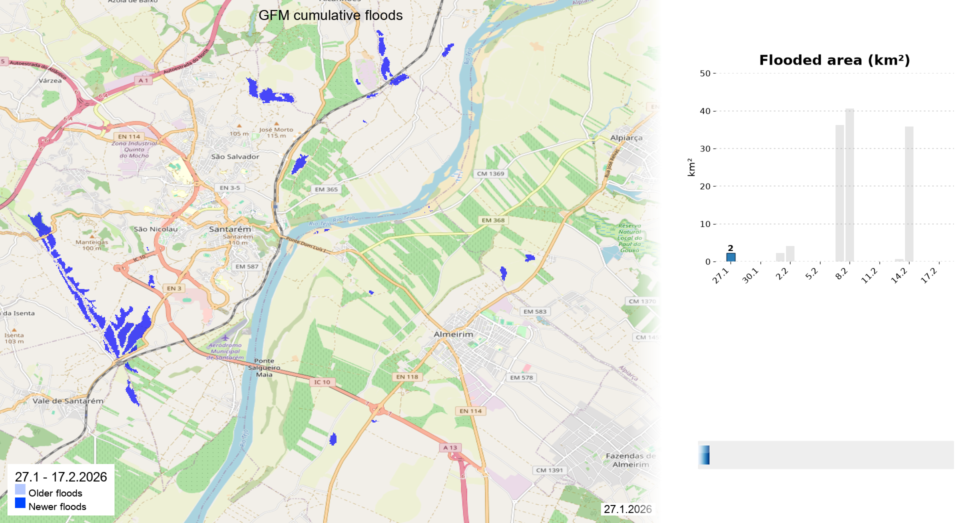
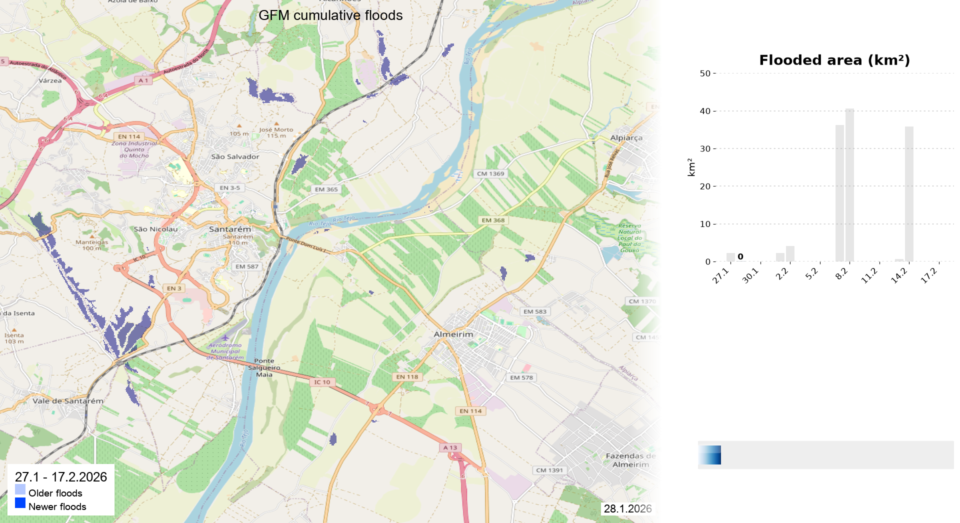
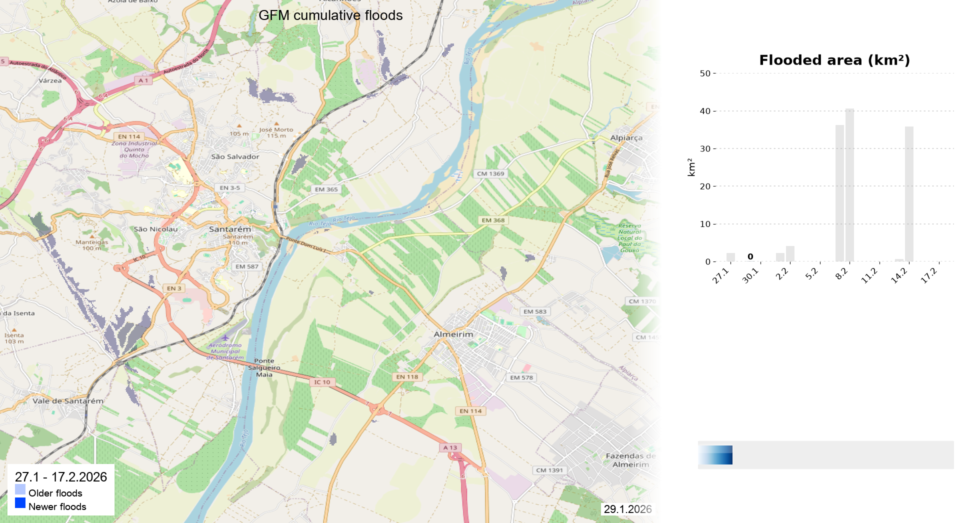
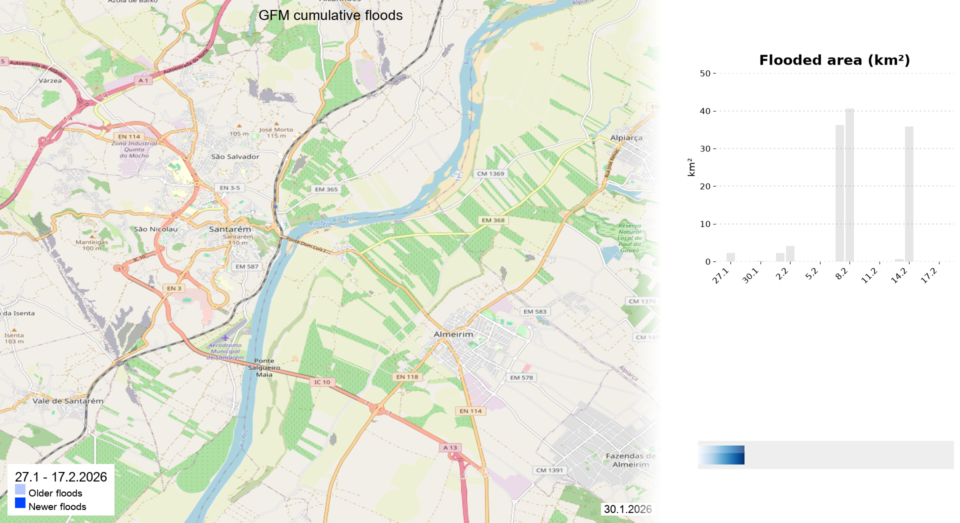
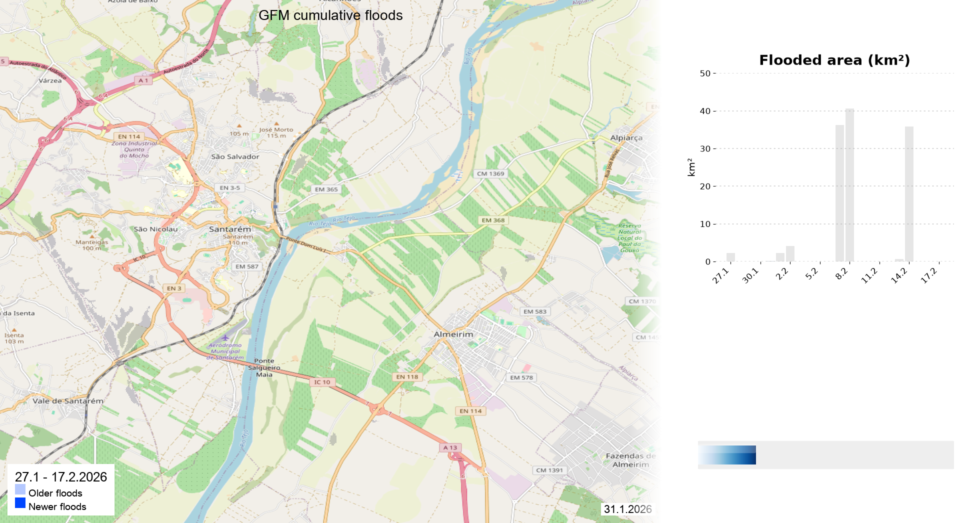
...
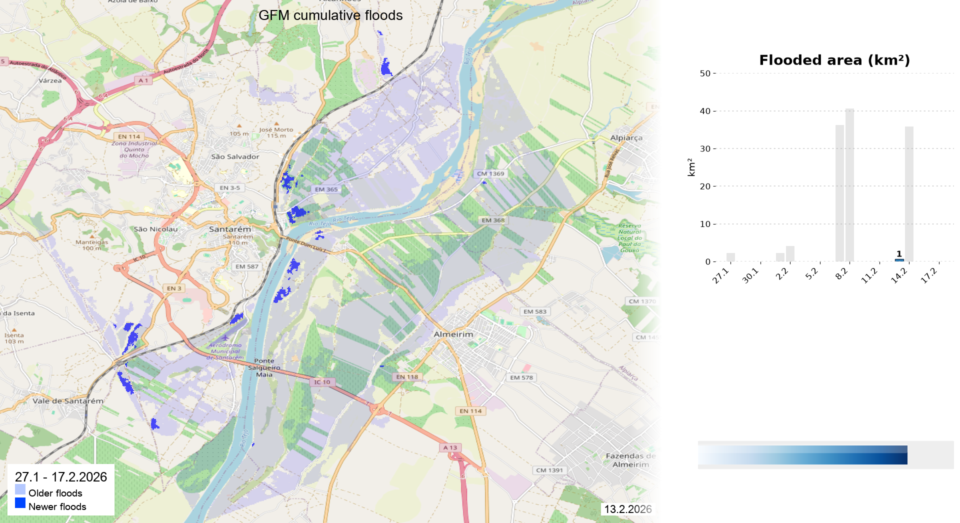
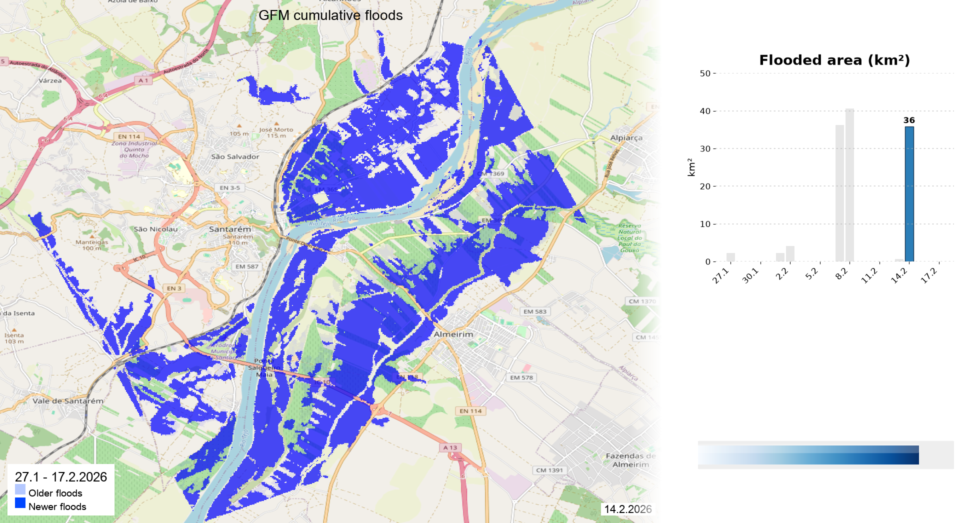
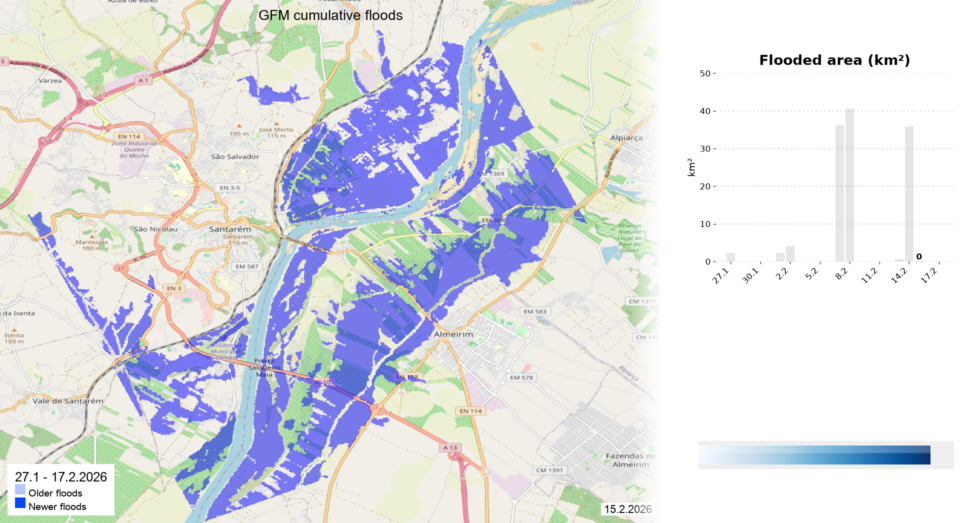
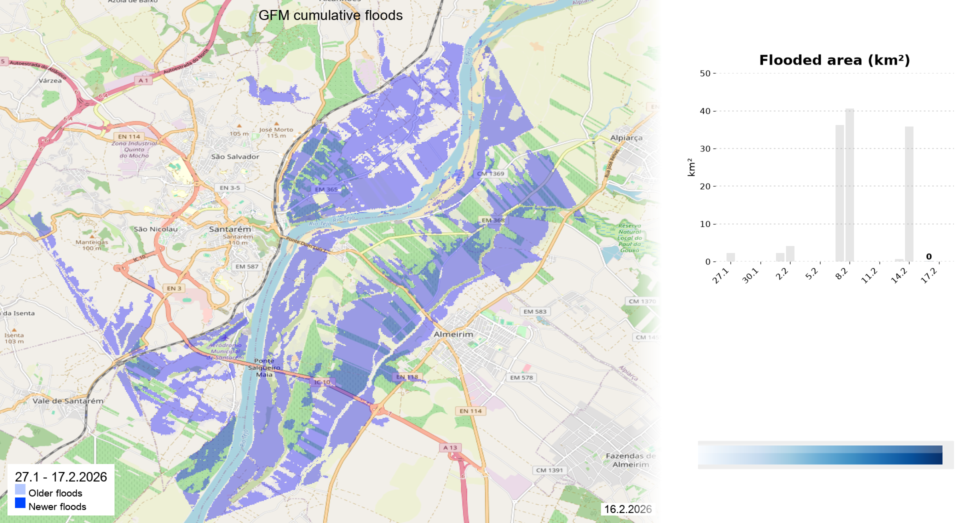
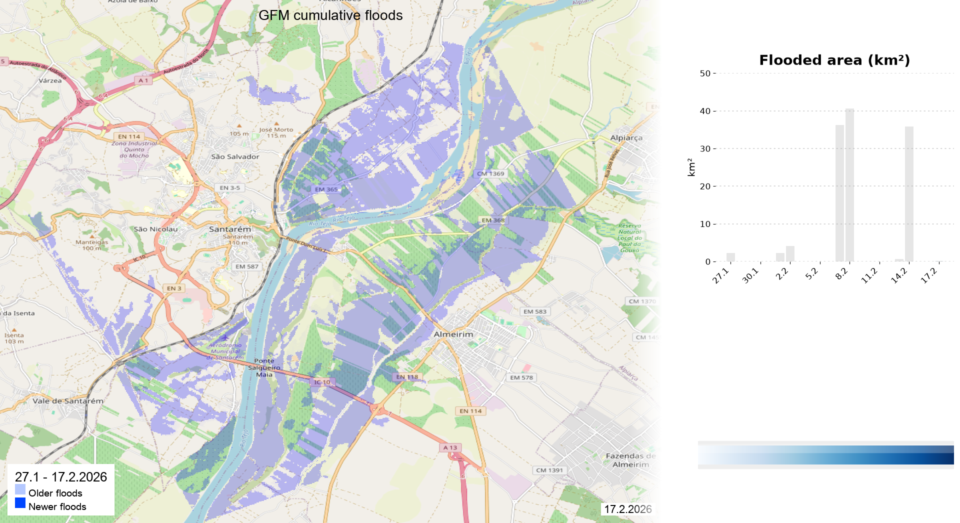

HTML(value='<div style="margin-top: 10px; padding: 10px; background: #f8f9fa; border: 1px solid #dee2e6; borde…

In [9]:
# --- Pillow compatibility for NEAREST (for resize) ---
try:
    # Pillow >=10
    from PIL.Image import Resampling as _PIL_Resampling
    _NEAREST = _PIL_Resampling.NEAREST
except Exception:
    _NEAREST = Image.NEAREST

# --- Allow large PNGs and silence decompression warnings ---
Image.MAX_IMAGE_PIXELS = None
warnings.simplefilter("ignore", Image.DecompressionBombWarning)

# ---------- Parameters ----------
overlay_dir = globals().get("FLOOD_DIR", "flood_frames")
ZOOM = 9              # min basemap zoom; effective zoom auto-scales UP for small AOIs (see _auto_zoom)
CHART_WIDTH_FRACTION = 0.45
TARGET_OUT_WIDTH = 1920
USER_AGENT = "Mozilla/5.0 (video-export; OSM tiles via requests)"
TIMEOUT = 10
FADE_HALFLIFE = 2.0  # frames until an older flood fades to 50% opacity (smaller = fades faster)

_scale = TARGET_OUT_WIDTH / 1920.0
TITLE_SIZE      = int(20 * _scale)
AXIS_LABEL_SIZE = int(14 * _scale)
TICK_SIZE       = int(12 * _scale)
VALUE_SIZE      = int(12 * _scale)
MAP_TITLE_PX = int(26 * _scale)
MAP_LABEL_PX = int(20 * _scale)
MAP_DATE_PX  = int(22 * _scale)

# ---------- Helpers ----------
def _font(px):
    for p in ["DejaVuSans.ttf","/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
              "/System/Library/Fonts/Supplemental/Arial Unicode.ttf","/Library/Fonts/Arial.ttf"]:
        try:
            return ImageFont.truetype(p, px)
        except:
            pass
    return ImageFont.load_default()

def _label_to_date(s):
    m = re.search(r'\d{4}-\d{2}-\d{2}', str(s))
    if m:
        try:
            return datetime.strptime(m.group(0), "%Y-%m-%d").date()
        except:
            pass
    try:
        return getattr(s, 'astype')('datetime64[D]').astype('datetime64[ms]').tolist().date()
    except:
        return None

def _build_range_text(labels_):
    ds = [d for d in (_label_to_date(x) for x in labels_) if d is not None]
    if not ds: return "Flood period"
    d1, d2 = min(ds), max(ds)
    return f"{d1.day}.{d1.month} - {d2.day:02d}.{d2.month}.{d2.year}"

def _format_frame_date(label):
    d = _label_to_date(label)
    return f"{d.day}.{d.month}.{d.year}" if d else str(label)

def _pick_xticks(n, target=8):
    if n <= 1: return [0]
    step = max(1, round(n / target))
    idx = list(range(0, n, step))
    if (n-1) not in idx: idx.append(n-1)
    return sorted(set(idx))

def _nice_upper(x):
    if x <= 0: return 1.0
    k = 10 ** math.floor(math.log10(x))
    for m in [1, 2, 2.5, 5, 10]:
        if m * k >= x * 1.05: return m * k
    return 10 * k

def _pad_even_rgb(arr):
    # FFmpeg (yuv420p) needs even dimensions -> pad 1px if needed.
    h, w = arr.shape[:2]
    ph = h % 2
    pw = w % 2
    if ph or pw:
        arr = np.pad(arr, ((0, ph), (0, pw), (0, 0)), mode="edge")
    return arr

# ---------- OSM XYZ ----------
ORIGIN = 20037508.342789244
TILE   = 256

def _latlon_to_tile(lat, lon, z):
    lat_rad = math.radians(lat); n = 2.0 ** z
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.log(math.tan(lat_rad) + 1.0 / math.cos(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile

def _tile_bounds_3857(x, y, z):
    n = 2 ** z; ts = (2 * ORIGIN) / n
    xmin = -ORIGIN + x * ts; xmax = xmin + ts; ymax = ORIGIN - y * ts; ymin = ymax - ts
    return xmin, ymin, xmax, ymax, ts

def _fetch_osm_xyz_mosaic(bounds_4326, z):
    (min_lat, min_lon), (max_lat, max_lon) = bounds_4326
    x0, y1 = _latlon_to_tile(min_lat, min_lon, z); x1, y0 = _latlon_to_tile(max_lat, max_lon, z)
    if x0 > x1: x0, x1 = x1, x0
    if y0 > y1: y0, y1 = y1, y0
    cols = x1 - x0 + 1; rows = y1 - y0 + 1
    mosaic = Image.new("RGB", (cols*TILE, rows*TILE), (255,255,255))
    session = requests.Session(); session.headers.update({"User-Agent": USER_AGENT})
    subs = ["a","b","c"]; k=0
    for yy in range(y0, y1+1):
        for xx in range(x0, x1+1):
            sub = subs[k%3]; k+=1
            url = f"https://{sub}.tile.openstreetmap.org/{z}/{xx}/{yy}.png"
            try:
                r = session.get(url, timeout=TIMEOUT); r.raise_for_status()
                tile = Image.open(io.BytesIO(r.content)).convert("RGB")
            except Exception:
                tile = Image.new("RGB", (TILE, TILE), (255,255,255))
            mosaic.paste(tile, ((xx-x0)*TILE, (yy-y0)*TILE))
    xmin, ymin, xmax, ymax, ts = _tile_bounds_3857(x0, y0, z)
    px = ts / TILE
    transform = Affine(px, 0, xmin, 0, -px, ymax)
    return np.array(mosaic, dtype=np.uint8), transform

def _osm_to_overlay_grid(bounds_4326, H, W, z):
    # FIX: no overwriting of class attributes; clean from_epsg
    rgb_merc, src_transform = _fetch_osm_xyz_mosaic(bounds_4326, z)
    src_crs = rasterio.crs.CRS.from_epsg(3857)
    dst_crs = rasterio.crs.CRS.from_epsg(4326)

    (min_lat, min_lon), (max_lat, max_lon) = bounds_4326
    west, south, east, north = float(min_lon), float(min_lat), float(max_lon), float(max_lat)
    dst_transform = from_bounds(west, south, east, north, W, H)

    dst = np.zeros((3, H, W), dtype=np.uint8)
    for b in range(3):
        reproject(
            source=rgb_merc[:, :, b],
            destination=dst[b],
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )
    return np.transpose(dst, (1, 2, 0))

# ---------- Load per-frame flood masks (in-memory first, disk fallback) ----------
if 'bounds' not in globals():
    raise RuntimeError("Missing bounds = [[min_lat,min_lon],[max_lat,max_lon]] (EPSG:4326).")

def _frame_source():
    """(labels, getter, source_name) where getter(k) -> full-res boolean flood mask (H0xW0).
    Reuses the flood cube already in RAM (no PNG round-trip); falls back to the exported PNGs
    so the cell still works if run on its own in a fresh kernel."""
    fd = globals().get("flood_data")
    if fd is not None and getattr(fd, "ndim", 0) == 3 and fd.shape[0] > 0:
        times = fd["time"].values
        labels = [f"flood_{k:02d}_{np.datetime_as_string(t, unit='D')}" for k, t in enumerate(times)]
        def getter(k, _fd=fd):
            v = np.asarray(_fd.isel(time=k).values)
            return (v > 0) & (v < 254)
        return labels, getter, "memory (flood_data)"
    files = sorted(f for f in os.listdir(overlay_dir) if f.lower().endswith(".png"))
    if not files:
        raise RuntimeError(f"No flood masks in memory and no PNGs in '{overlay_dir}'.")
    labels = [os.path.splitext(f)[0] for f in files]
    def getter(k, _files=files):
        A = np.array(Image.open(os.path.join(overlay_dir, _files[k])).convert("RGBA"))
        return (A[..., 2] > 0) & (A[..., 3] > 0)
    return labels, getter, "disk PNGs"

labels_video, _get_mask, _mask_src = _frame_source()
print(f"🧩 Frame source: {_mask_src} — {len(labels_video)} frames")

# Days with no satellite pass (filled into the calendar upstream) -> flagged red in the chart/video.
_nd_set = set(globals().get("no_data_days", set()))
no_data_flags = []
for _lbl in labels_video:
    _d = _label_to_date(_lbl)
    no_data_flags.append(bool(_d is not None and _d.isoformat() in _nd_set))
print(f"\U0001f6a9 No-satellite days flagged: {sum(no_data_flags)} / {len(no_data_flags)}")

H0, W0 = _get_mask(0).shape

map_w   = int(TARGET_OUT_WIDTH / (1.0 + CHART_WIDTH_FRACTION))
chart_w = TARGET_OUT_WIDTH - map_w
map_h   = int(round(map_w * (H0 / W0)))   # keep aspect ratio
if map_h % 2:  # enforce even height for H.264
    map_h += 1
out_w, out_h = TARGET_OUT_WIDTH, map_h

# ---------- Pixel area weighting (km^2 per row at given lat) ----------
(min_lat, min_lon), (max_lat, max_lon) = bounds
dlon_rad = math.radians((max_lon - min_lon) / W0)
dlat     = (max_lat - min_lat) / H0
phi_top    = np.radians(max_lat - np.arange(0, H0)   * dlat)
phi_bottom = np.radians(max_lat - np.arange(1, H0+1) * dlat)
row_area_m2 = (6378137.0 ** 2) * dlon_rad * np.abs(np.sin(phi_top) - np.sin(phi_bottom))

areas_km2 = []
resized_masks = []  # downscaled masks to (map_h, map_w)
for _k in range(len(labels_video)):
    mask_full = _get_mask(_k)
    counts = mask_full.sum(axis=1).astype(np.float64)
    areas_km2.append(float(np.dot(counts, row_area_m2)) / 1e6)
    m_img = Image.fromarray((mask_full.astype(np.uint8) * 255)).convert("L").resize((map_w, map_h), _NEAREST)
    resized_masks.append(np.array(m_img, dtype=np.uint8) > 0)

areas_km2 = np.array(areas_km2, dtype=np.float64)
N = len(resized_masks)

# ---------- Basemap to target grid ----------
def _auto_zoom(bounds_4326, target_w_px, z_min=ZOOM, z_max=18):
    """Pick an OSM zoom so the basemap ~matches the output resolution.
    Small AOIs otherwise reuse low-zoom tiles that get upscaled -> blurry basemap."""
    (min_lat, min_lon), (max_lat, max_lon) = bounds_4326
    dlon = max(1e-9, float(max_lon - min_lon))
    z = round(math.log2(target_w_px * 360.0 / (256.0 * dlon)))
    return int(max(z_min, min(z_max, z)))

zoom_eff = _auto_zoom(bounds, map_w)
print(f"🗺️ Basemap zoom (auto): {zoom_eff}")
basemap_rgb = _osm_to_overlay_grid(bounds, map_h, map_w, zoom_eff)

# ---------- Bar chart (pre-render per frame) ----------
def _short_label(lbl):
    d = _label_to_date(lbl)
    return f"{d.day}.{d.month}" if d else str(lbl)

y_max = _nice_upper(float(np.max(areas_km2))) if len(areas_km2) else 1.0
tick_idx    = _pick_xticks(N, target=8)
tick_labels = [_short_label(lbl) for lbl in labels_video]

def _render_all_charts(areas_km2, width_px, height_px, y_max, tick_idx, tick_labels, no_data_flags=None):
    """Build the bar-chart figure ONCE and only update the highlighted bar, its value label
    and the (cheap) progress bar per frame — instead of creating/closing a new figure for each
    of the N frames. Output is pixel-identical to the old per-frame renderer."""
    Nloc = len(areas_km2)
    _dpi = 100  # render at target size (was 140 => 1.4x supersample + downscale); ~1.5x faster, ~same look
    fig = plt.figure(figsize=(width_px/100, height_px/100), dpi=_dpi)
    ax  = fig.add_subplot(111)
    x = np.arange(Nloc)
    bars = ax.bar(x, areas_km2, width=0.85, linewidth=0)
    for b in bars:
        b.set_color("#e6e6e6"); b.set_alpha(1.0)
    # per-day no-satellite flags (used to skip the numeric value on days with no observation)
    nd = list(no_data_flags) if no_data_flags is not None else [False] * Nloc
    if len(nd) < Nloc:
        nd += [False] * (Nloc - len(nd))
    ax.set_title("Flooded area (km²)", pad=12, fontsize=TITLE_SIZE, weight="bold")
    ax.set_ylabel("km²", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.set_ylim(0, max(y_max, 1.0))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([tick_labels[t] for t in tick_idx], rotation=45, ha="right", fontsize=TICK_SIZE)
    for s in ["top","right","left","bottom"]: ax.spines[s].set_visible(False)
    ax.grid(axis="y", linestyle=(0,(2,3)), linewidth=1.2, alpha=0.6)
    grad = np.linspace(0, 1, 512).reshape(1, -1)
    fig.subplots_adjust(left=0.18, right=0.98, top=0.86, bottom=0.50)
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")

    imgs = []
    value_txt = None
    pb_ax = None
    for idx in range(Nloc):
        for j, b in enumerate(bars):
            if j == idx:
                b.set_color("#1f77b4"); b.set_alpha(0.95); b.set_edgecolor("#0d2742"); b.set_linewidth(1.0)
            else:
                b.set_color("#e6e6e6"); b.set_alpha(1.0); b.set_edgecolor("none"); b.set_linewidth(0.0)
        if value_txt is not None:
            value_txt.remove(); value_txt = None
        if Nloc and not nd[idx]:
            value_txt = ax.text(idx, areas_km2[idx] * 1.01, f"{areas_km2[idx]:,.0f}",
                                ha="center", va="bottom", fontsize=VALUE_SIZE, fontweight="bold")
        # progress bar rebuilt fresh each frame (identical to the old renderer), cheap overlay axis
        if pb_ax is not None:
            pb_ax.remove()
        curr = min(max(1, idx + 1), max(1, Nloc))
        pb_ax = fig.add_axes([0.12, 0.10, 0.86, 0.06])
        pb_ax.set_xlim(0, max(1, Nloc)); pb_ax.set_ylim(0, 1); pb_ax.axis("off")
        pb_ax.add_patch(FancyBboxPatch((0, 0.2), max(1, Nloc), 0.6, boxstyle="round,pad=0.15,rounding_size=0.25",
                        linewidth=0, facecolor="#eeeeee"))
        im = pb_ax.imshow(grad, extent=[0, curr, 0.2, 0.8], cmap=plt.get_cmap("Blues"), aspect="auto", zorder=2)
        clip = FancyBboxPatch((0, 0.2), curr, 0.6, boxstyle="round,pad=0.15,rounding_size=0.25",
                              linewidth=0, facecolor="none")
        pb_ax.add_patch(clip)
        im.set_clip_path(clip)
        pb_ax.add_patch(FancyBboxPatch((0, 0.68), curr, 0.06, boxstyle="round,pad=0.12,rounding_size=0.25",
                        linewidth=0, facecolor=(1,1,1,0.25), zorder=3))
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=_dpi)
        buf.seek(0)
        _img = Image.open(buf).convert("RGB")
        if _img.size != (width_px, height_px):
            _img = _img.resize((width_px, height_px), Image.BICUBIC)
        imgs.append(np.array(_img, dtype=np.uint8))
    plt.close(fig)
    return imgs

chart_imgs = _render_all_charts(areas_km2, chart_w, map_h, y_max, tick_idx, tick_labels, no_data_flags)

# ---------- Static, opaque legend (no flicker) ----------
def _make_legend_tile(range_text, W, H, legend_max_frac=(0.20, 0.12)):
    f_title = _font(MAP_TITLE_PX)
    f_label = _font(MAP_LABEL_PX)
    pad  = max(6, int(min(W,H)*0.015))
    gap  = max(4, pad//2)
    sw = sh = max(18, int(min(W,H)*0.02))

    max_w = int(W * legend_max_frac[0])
    max_h = int(H * legend_max_frac[1])

    tmp = Image.new("RGBA", (1,1))
    dtmp = ImageDraw.Draw(tmp)
    def _measure(dr, txt, f):
        if hasattr(dr, "textbbox"):
            l,t,r,b = dr.textbbox((0,0), txt, font=f); return (r-l, b-t)
        return dr.textsize(txt, font=f)

    twt, tht     = _measure(dtmp, range_text, f_title)
    w_new, h_new = _measure(dtmp, "Newer floods", f_label)
    w_old, h_old = _measure(dtmp, "Older floods", f_label)
    text_w = max(w_new, w_old)

    inner_w = max(twt, sw + gap + text_w)
    inner_h = tht + gap + sh + gap + sh
    box_w = min(pad*2 + inner_w, max_w)
    box_h = min(pad*2 + inner_h, max_h)

    tile = Image.new("RGBA", (box_w, box_h), (255,255,255,255))
    dr = ImageDraw.Draw(tile)

    tx = pad; ty = pad//2
    dr.text((tx, ty), range_text, fill=(0,0,0), font=f_title)

    y1 = ty + tht + gap*2 
    dr.rectangle((tx, y1, tx + sw, y1 + sh), fill=(180,200,255))
    dr.text((tx + sw + gap, y1 + (sh - h_new)//2), "Older floods", fill=(0,0,0), font=f_label)

    y2 = y1 + sh + gap
    dr.rectangle((tx, y2, tx + sw, y2 + sh), fill=(0,70,255))
    dr.text((tx + sw + gap, y2 + (sh - h_new)//2), "Newer floods", fill=(0,0,0), font=f_label)

    pos = (pad, H - box_h - pad)   # bottom-left
    return tile, pos

def _draw_date_only(pil_img, date_text):
    if not date_text: return
    f = _font(MAP_DATE_PX)
    dr = ImageDraw.Draw(pil_img)
    W, H = pil_img.size
    pad = max(6, int(min(W, H) * 0.02))
    t = str(date_text)
    if hasattr(dr,"textbbox"):
        x, y = W - pad, H - pad
        x0,y0,x1,y1 = dr.textbbox((x, y), t, font=f, anchor="rb")
        dr.rectangle((x0-6, y0-4, x1+6, y1+4), fill=(255,255,255))
        dr.text((x, y), t, fill=(0,0,0), font=f, anchor="rb")
    else:
        tw, th = dr.textsize(t, font=f)
        x = W - pad - tw; y = H - pad - th
        dr.rectangle((x-6, y-4, x+tw+6, y+th+4), fill=(255,255,255))
        dr.text((x, y), t, fill=(0,0,0), font=f)

# ---------- Build frames ----------
range_text = _build_range_text(labels_video)
LEG_TILE, LEG_POS = _make_legend_tile(range_text, map_w, map_h)

blue_sum  = np.zeros((map_h, map_w), dtype=np.uint32)  # sum of indices where flood occurred
last_day  = np.zeros((map_h, map_w), dtype=np.uint16)  # last frame index with flood

frames = []
for i, msk in enumerate(resized_masks, start=1):
    if msk.any():
        blue_sum[msk] += i
        last_day[msk]  = i

    blue  = (255.0 * (blue_sum / float(i))).astype(np.float32)
    # Fade older floods by AGE (frames since a pixel was last flooded) with a half-life.
    # Smaller FADE_HALFLIFE -> older floods disappear faster. last_day==0 -> never flooded.
    age   = (i - last_day.astype(np.int32)).astype(np.float32)
    alpha = np.where(last_day > 0, 180.0 * 0.5 ** (age / float(FADE_HALFLIFE)), 0.0).astype(np.float32)

    ov = np.zeros((map_h, map_w, 4), dtype=np.uint8)
    ov[..., 2] = np.clip(blue,  0, 255).astype(np.uint8)   # Blue
    ov[..., 3] = np.clip(alpha, 0, 255).astype(np.uint8)   # Alpha

    bg = Image.fromarray(basemap_rgb.copy(), mode="RGB")
    ov_img = Image.fromarray(ov, mode="RGBA")
    bg.paste(ov_img, mask=ov_img.split()[3])

    # static legend + date
    bg.paste(LEG_TILE, LEG_POS, LEG_TILE)
    frame_date = _format_frame_date(labels_video[i-1])
    _draw_date_only(bg, frame_date)

    # ---- Title (centered) ----
    draw = ImageDraw.Draw(bg)
    title_text = "GFM cumulative floods"
    font_title = _font(28)
    if hasattr(draw, "textbbox"):
        x0, y0, x1, y1 = draw.textbbox((0, 0), title_text, font=font_title)
        text_w, text_h = (x1 - x0), (y1 - y0)
    else:
        bx0, by0, bx1, by1 = font_title.getbbox(title_text)
        text_w, text_h = (bx1 - bx0), (by1 - by0)
    draw.text(((bg.width - text_w) // 2, 10), title_text, font=font_title, fill=(0, 0, 0))

    # stitch [ MAP | CHART ]
    canvas = np.full((map_h, out_w, 3), 255, dtype=np.uint8)  # white background for chart
    map_arr = np.array(bg, dtype=np.uint8)

    fade_width = max(8, int(map_w * 0.05))
    grad = np.linspace(1.0, 0.0, fade_width, dtype=np.float32)[None, :, None]
    grad = np.repeat(grad, map_h, axis=0)  # (map_h, fade_width, 1)

    left_part = map_arr[:, :map_w - fade_width, :]
    right_fade_src = map_arr[:, map_w - fade_width:map_w, :].astype(np.float32)
    right_fade = (right_fade_src * grad + 255.0 * (1.0 - grad)).astype(np.uint8)

    canvas[:, :map_w - fade_width, :] = left_part
    canvas[:, map_w - fade_width:map_w, :] = right_fade
    canvas[:, map_w:, :] = chart_imgs[i-1]

    frames.append(_pad_even_rgb(canvas))

fps = 5.0
print(f"✅ Frames: {len(frames)}, size={frames[0].shape}, fps={fps:.2f}")

# ---------- Export ----------
# GIF is a compatibility artifact -> downscale it (full-res stays in the MP4). ~5x faster encode + smaller file.
GIF_MAX_WIDTH = 960
def _downscale_frame(arr, max_w):
    im = Image.fromarray(arr)
    if im.width > max_w:
        im = im.resize((max_w, max(1, round(im.height * max_w / im.width))), Image.BILINEAR)
    return np.asarray(im)

gif_path = "flood_map_chart.gif"
gif_frames = [_downscale_frame(fr, GIF_MAX_WIDTH) for fr in frames]
imageio.mimsave(gif_path, gif_frames, duration=1.0/fps, loop=0)
print(f"🎞️ GIF: {gif_path}  ({gif_frames[0].shape[1]}×{gif_frames[0].shape[0]}, downscaled from {frames[0].shape[1]}px)")

mp4_path="flood_map_chart.mp4"
if shutil.which("ffmpeg"):
    try:
        with imageio.get_writer(
            mp4_path, fps=float(fps), codec="libx264", macro_block_size=None,
            ffmpeg_params=["-loglevel","error","-movflags","+faststart","-pix_fmt","yuv420p","-probesize","50M"]
        ) as w:
            for fr in frames: 
                w.append_data(fr)
        print(f"🎬 MP4: {mp4_path}")
    except Exception as e:
        print(f"⚠️ Direct MP4 failed: {e} -> re-encode from GIF")
        subprocess.run([
            "ffmpeg","-y","-loglevel","error","-i",gif_path,
            "-vf","scale=trunc(iw/2)*2:trunc(ih/2)*2",
            "-c:v","libx264","-pix_fmt","yuv420p","-movflags","+faststart", mp4_path
        ], check=True)
        print(f"🎬 MP4 (from GIF): {mp4_path}")

# ---------- Responsive time-series viewer with loop control (Colab-safe, same UI) ----------
# The interactive viewer is only a PREVIEW -> embed downscaled frames (full-res stays in the
# GIF/MP4 files). This is what dominated the notebook size and the browser load time.
VIEWER_MAX_WIDTH = 960
def _to_b64_png(arr, max_w=None):
    im = Image.fromarray(arr)
    if max_w and im.width > max_w:
        im = im.resize((max_w, max(1, round(im.height * max_w / im.width))), Image.BILINEAR)
    buf = io.BytesIO(); im.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")

frames_b64 = [_to_b64_png(fr, VIEWER_MAX_WIDTH) for fr in frames]
labels_js  = [str(x) for x in globals().get("labels_video", [str(i) for i in range(len(frames_b64))])]
N = len(frames_b64)
fps_init = float(globals().get("fps_default", 5.0))  # same default UI

html = f"""
<style>
  .controls-row {{
    display:flex; align-items:center; justify-content:space-between; gap:8px; width:100%;
    font-family:system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  }}
  .controls-left, .controls-right {{ display:flex; align-items:center; gap:8px; }}
  .btn {{
    padding:6px 10px; border-radius:6px; border:1px solid #ccc; background:#f7f7f7; cursor:pointer;
  }}
  .btn-success {{ background:#28a745; color:white; border-color:#1f7a33; }}
  .label, .index {{ font-size:14px; margin-left:4px; }}
  .slider {{ width:100%; }}
  .container {{ width:100%; }}
  .img-wrap {{ width:100%; display:flex; justify-content:center; }}
  .img-wrap > img {{ width:100%; height:auto; max-width:1200px; display:block; }}
</style>

<div class="container">
  <div class="img-wrap">
    <img id="flood_img" />
  </div>

  <input id="main_slider" class="slider" type="range" min="0" max="{N-1}" value="0" step="1" />

  <div class="controls-row">
    <div class="controls-left">
      <button id="btn_prev" class="btn">◀ Prev</button>
      <button id="btn_play" class="btn btn-success">Play ▶</button>
      <button id="btn_pause" class="btn">Pause ■</button>
      <button id="btn_next" class="btn">Next ▶</button>
      <label class="btn">
        <input id="loop_toggle" type="checkbox" checked style="margin-right:6px;"> Loop
      </label>
    </div>
    <div class="controls-right">
      <label for="fps_slider">fps</label>
      <input id="fps_slider" type="range" min="5" max="25" step="0.5" value="{fps_init}" />
      <span id="fps_val" class="label">{fps_init}</span>
      <span id="index" class="index">0 / {N-1}</span>
    </div>
  </div>

  <div id="label" class="label"></div>
</div>

<script>
  (function() {{
  const frames = {json.dumps(frames_b64)};
  const labels = {json.dumps(labels_js)};
  let i = 0;
  let timer = null;

  const img = document.getElementById('flood_img');
  const slider = document.getElementById('main_slider');
  const idx = document.getElementById('index');
  const lbl = document.getElementById('label');
  const btnPrev = document.getElementById('btn_prev');
  const btnNext = document.getElementById('btn_next');
  const btnPlay = document.getElementById('btn_play');
  const btnPause = document.getElementById('btn_pause');
  const loopToggle = document.getElementById('loop_toggle');
  const fpsSlider = document.getElementById('fps_slider');
  const fpsVal = document.getElementById('fps_val');

  function render(k) {{
    i = Math.max(0, Math.min(frames.length - 1, k));
    img.src = frames[i];
    slider.value = i;
    idx.textContent = i + " / " + (frames.length - 1);
    lbl.textContent = labels[i] || "";
  }}

  function intervalMs() {{
    const fps = Math.max(0.1, parseFloat(fpsSlider.value || "10"));
    return Math.max(40, 1000 / fps);
  }}

  function play() {{
    if (timer) return;
    timer = setInterval(() => {{
      if (i >= frames.length - 1) {{
        if (loopToggle.checked) {{
          i = 0;
        }} else {{
          pause();
          return;
        }}
      }} else {{
        i += 1;
      }}
      render(i);
    }}, intervalMs());
  }}

  function pause() {{
    if (timer) {{
      clearInterval(timer);
      timer = null;
    }}
  }}

  // Handlers
  slider.addEventListener('input', e => render(parseInt(e.target.value)));
  btnPrev.addEventListener('click', () => render(i - 1));
  btnNext.addEventListener('click', () => render(i + 1));
  btnPlay.addEventListener('click', play);
  btnPause.addEventListener('click', pause);

  fpsSlider.addEventListener('input', () => {{
    fpsVal.textContent = fpsSlider.value;
    if (timer) {{ pause(); play(); }}
  }});

  // init
  render(0);
  play();
  }})();
</script>
"""
display(HTML(html))

# ==== INFO PANEL: number of images and their dates ====
try:
    image_dates = sorted(set(
        item.datetime.strftime("%Y-%m-%d") if item.datetime else "unknown"
        for item in items
    ))
    n_images = len(items)
    # split the full calendar into flood / no-flood / no-satellite days
    _flood_d, _dry_d, _gap_d = [], [], []
    _cal_days = []
    for _lbl, _area, _ndf in zip(labels_video, areas_km2, no_data_flags):
        _dt = _label_to_date(_lbl)
        _tag = f"{_dt.day}.{_dt.month}" if _dt else str(_lbl)
        if _ndf:
            _gap_d.append(_tag); _cat = "gap"
        elif _area > 0:
            _flood_d.append(_tag); _cat = "flood"
        else:
            _dry_d.append(_tag); _cat = "dry"
        if _dt is not None:
            _cal_days.append((_dt, _cat, float(_area)))
    _obs = []
    for _x in image_dates:
        _d = _label_to_date(_x)
        _obs.append(f"{_d.day}.{_d.month}" if _d else str(_x))
    _obs_compact = ", ".join(_obs) if _obs else "N/A"
except NameError:
    image_dates = []
    n_images = 0
    _flood_d = _dry_d = _gap_d = []
    _obs_compact = "N/A"
    _cal_days = []

import calendar as _calmod
from datetime import date as _dtdate

_GAP_BG = "repeating-linear-gradient(45deg,#efefef,#efefef 3px,#dcdcdc 3px,#dcdcdc 6px)"

def _cal_cell_style(cat):
    if cat == "flood":
        return "background:#2471a3;color:#fff;"
    if cat == "dry":
        return "background:#d6eaf8;color:#1b4f72;"
    if cat == "gap":
        return "background:" + _GAP_BG + ";color:#999;"
    return "background:transparent;color:#ccc;"

def _build_calendar_html(cal_days):
    if not cal_days:
        return '<i style="color:#888;">No calendar data</i>'
    cat_of, area_of = {}, {}
    for _d, _cat, _area in cal_days:
        cat_of[_d] = _cat
        area_of[_d] = _area
    # sort all days and render only those in the data range
    all_dates = sorted(cat_of.keys())
    cells = []
    prev_mo = None
    for _dd in all_dates:
        # month label when month changes
        if _dd.month != prev_mo:
            if prev_mo is not None:
                cells.append('<div style="width:4px;"></div>')
            _lbl = f"{_calmod.month_abbr[_dd.month]}"
            cells.append(
                '<div style="font-weight:bold;font-size:9px;color:#555;'
                'display:flex;align-items:center;'
                'padding:0 3px;white-space:nowrap;">' + _lbl + '</div>'
            )
            prev_mo = _dd.month
        _cat = cat_of[_dd]
        if _cat == "flood":
            _tip = f"{_dd.isoformat()} - flood {area_of[_dd]:,.0f} km2"
        elif _cat == "dry":
            _tip = f"{_dd.isoformat()} - observed, no flood"
        else:
            _tip = f"{_dd.isoformat()} - no satellite observation"
        _style = _cal_cell_style(_cat)
        cells.append(
            f'<div title="{_tip}" style="{_style}border-radius:3px;text-align:center;'
            f'min-width:18px;padding:2px 1px;font-size:10px;">{_dd.day}</div>'
        )
    return ('<div style="display:flex;flex-wrap:nowrap;align-items:center;gap:1px;">'
            + "".join(cells) + '</div>')

def _cal_swatch(bg, border=""):
    _b = ("border:" + border + ";") if border else ""
    return ('<span style="display:inline-block;width:12px;height:12px;background:' + bg + ';'
            + _b + 'border-radius:3px;vertical-align:middle;margin-right:3px;"></span>')

_legend = (
    '<div style="margin-bottom:6px;font-size:12px;">'
    + _cal_swatch("#2471a3") + f'Flood ({len(_flood_d)}) &nbsp; '
    + _cal_swatch("#d6eaf8", "1px solid #aed6f1") + f'No flood ({len(_dry_d)}) &nbsp; '
    + _cal_swatch(_GAP_BG) + f'No satellite ({len(_gap_d)})'
    + '</div>'
)

info_html = (
    '<div style="margin-top: 10px; padding: 10px; background: #f8f9fa; '
    'border: 1px solid #dee2e6; border-radius: 6px; font-family: sans-serif; font-size: 13px; '
    'line-height: 1.6;">'
    '<div style="margin-bottom: 6px;">'
    f'<b>\U0001f4e1 Satellite images found (crossed your AOI):</b> {n_images}<br>'
    f'<b>\U0001f4c5 Observation dates:</b> {len(image_dates)}'
    + '</div>'
    + _legend
    + '<div style="overflow-x:auto;white-space:nowrap;">'
    + _build_calendar_html(_cal_days)
    + '</div>'
    + '</div>'
)
display(widgets.HTML(value=info_html))
